На этом семинаре поработаем с продвинутыми фреймворками для диффузионок на примере уже знакомовой вам экосистемы huggingface

In [1]:
!pip install diffusers accelerate compel gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 25.6 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylin

In [ ]:
from diffusers import AutoPipelineForText2Image
import torch

pipe_txt2img = AutoPipelineForText2Image.from_pretrained(
    "dreamlike-art/dreamlike-photoreal-2.0", torch_dtype=torch.float16, use_safetensors=True
).to("cuda")

prompt = "cinematic photo of Godzilla eating sushi with a cat in a izakaya, 35mm photograph, film, professional, 4k, highly detailed"
generator = torch.Generator(device="cpu").manual_seed(37)
image = pipe_txt2img(prompt, generator=generator).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

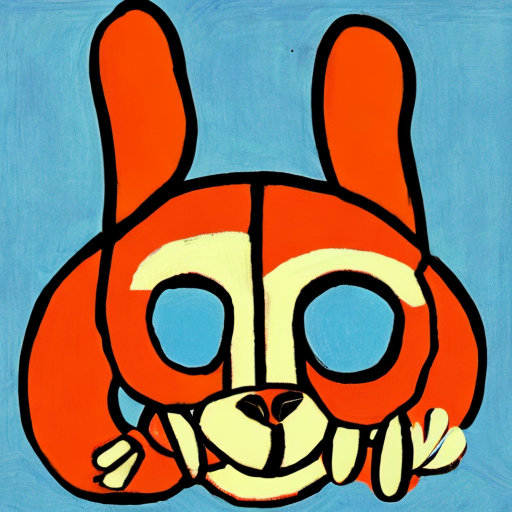

In [6]:
from diffusers import DiffusionPipeline
import torch

seed = torch.Generator("cuda").manual_seed(0)


pipeline = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1-base",
                                             # Необязательные параметры
                                            #  generator=seed, torch_dtype=torch.float16,
                                            #  num_inference_steps=10,
                                            #  height=256, width=256,
                                            #  guidance_scale=10
                                             )


prompt = "An image of a squirrel in Picasso style"
image = pipeline(prompt=prompt).images[0]

image

In [ ]:
promt = "An image of a squirrel in Picasso style"
negative_prompt = "ugly, bad anatomy"

image = pipeline(promt=promt, negative_prompt=negative_prompt).images[0]

In [ ]:
from compel import Compel
compel = Compel(tokenizer=pipeline.tokenizer, text_encoder=pipeline.text_encoder)

prompt = "sky image, sun++ clouds--"
conditioning = compel([prompt])

image = pipeline(prompt_embeds=conditioning).images[0]
image

In [2]:
from diffusers import DiffusionPipeline

pipeline = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1-base")
pipeline

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.27.2",
  "_name_or_path": "stabilityai/stable-diffusion-2-1-base",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

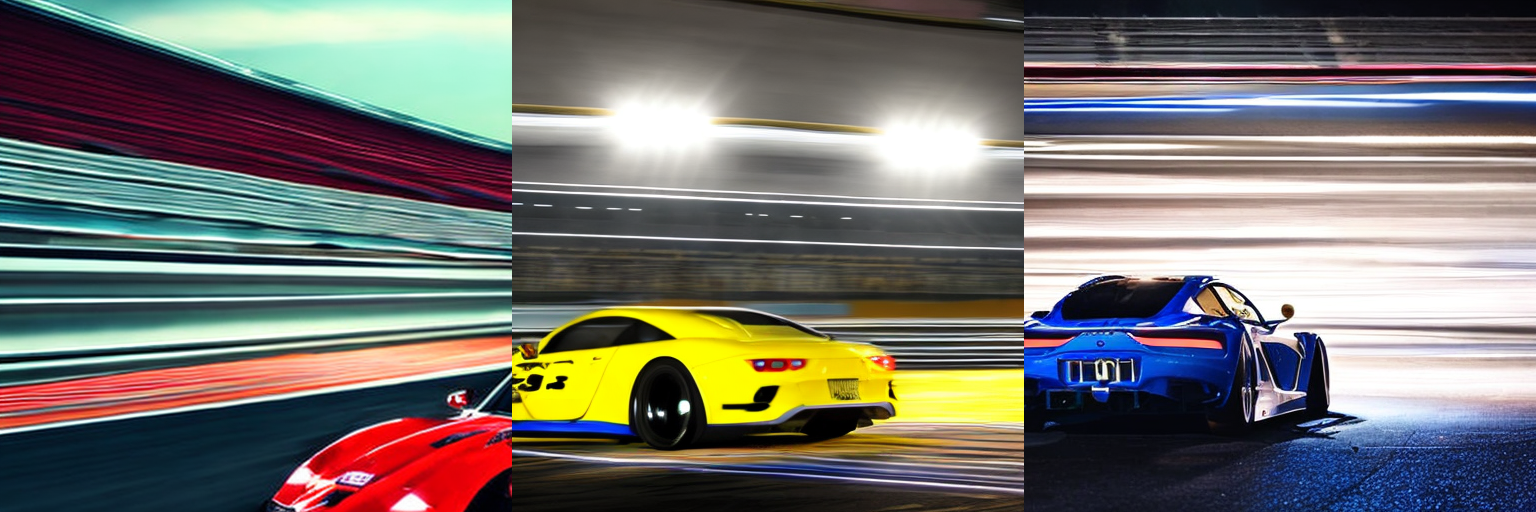

In [5]:
from diffusers import DiffusionPipeline
import torch
from PIL import Image

seed = torch.Generator("cuda").manual_seed(0)


pipeline = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1-base",
                                             # Необязательные параметры
                                             generator=seed,
                                            #  torch_dtype=torch.float16,
                                             num_inference_steps=10,
                                             height=256, width=256,
                                            #  guidance_scale=10
                                             )

# Функция выводит несколько изображений
def image_grid(imgs, rows=2, cols=2):
    w, h = imgs[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))

    return grid

# Запросы
prompts = [
    'red car at night on a racing track',
    'yellow car at night on a racing track',
    'blue car at night on a racing track'
]

images = pipeline(prompts).images


image_grid(images, rows=1, cols=3)

In [ ]:
from diffusers import EulerDiscreteScheduler

pipeline = DiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
pipeline.scheduler.compatibles


In [ ]:
# Меняем шедулер
pipeline.scheduler = EulerDiscreteScheduler.from_config(pipeline.scheduler.config)

In [ ]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
  "stabilityai/sd-vae-ft-mse",
  torch_dtype=torch.float16
).to("cuda")

pipeline.vae = vae

In [ ]:
Image.open('https://habrastorage.org/r/w1560/getpro/habr/upload_files/8f5/000/11f/8f500011f276266c51eeed23196d49d7.png').convert("RGB").thumbnail((768, 768))

# Im2Im

In [ ]:
import requests
from io import BytesIO
IMG_URL = ''

init_image = Image.open(BytesIO(requests.get(IMG_URL).content)).convert("RGB").thumbnail((768, 768))

prompt = "forest owl, pencil drawing"
image = pipeline(prompt=prompt, image=init_image).images[0]

# Inpainting

In [ ]:
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image

pipeline = StableDiffusionInpaintPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
).to("cuda")

init_image = Image.open()
mask_image = Image.open()

prompt = "teddy bear, sitting on a park bench"

image = pipeline(
  prompt=prompt,
  image=init_image,
  mask_image=mask_image
).images[0]
image

In [ ]:
import gradio as gr
gr.Interface.from_pipeline(pipeline)

# Adapters

In [ ]:
from diffusers import DiffusionPipeline
import torch

pipeline = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16
).to("cuda")
pipeline.load_lora_weights("nerijs/pixel-art-xl", weight_name="pixel-art-xl.safetensors", adapter_name="pixel")
pipeline.fuse_lora(lora_scale=0.7)
pipeline.enable_lora()
pipeline.get_active_adapters()
# pipeline.unload_lora_weights()

In [ ]:
pipeline.load_lora_weights(
    "jbilcke-hf/sdxl-cinematic-1", weight_name="pytorch_lora_weights.safetensors", adapter_name="cinematic"
)
pipeline.load_lora_weights("nerijs/pixel-art-xl", weight_name="pixel-art-xl.safetensors", adapter_name="pixel")
pipeline.set_adapters(["cinematic", "pixel"], adapter_weights=[0.5, 0.5])

# Textual inversion

In [ ]:
from diffusers import AutoPipelineForText2Image
import torch

pipeline = AutoPipelineForText2Image.from_pretrained("runwayml/stable-diffusion-v1-5")

# Example 1
pipeline.load_textual_inversion("sd-concepts-library/gta5-artwork")
pipeline.load_textual_inversion("sd-concepts-library/moeb-style")

# Remove all token embeddings
pipeline.unload_textual_inversion()

# Example 2
pipeline.load_textual_inversion("sd-concepts-library/moeb-style")
pipeline.load_textual_inversion("sd-concepts-library/gta5-artwork")

# Remove just one token
pipeline.unload_textual_inversion("<moe-bius>")

# Example 3: unload from SDXL
pipeline = AutoPipelineForText2Image.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0")
embedding_path = hf_hub_download(repo_id="linoyts/web_y2k", filename="web_y2k_emb.safetensors", repo_type="model")

# load embeddings to the text encoders
state_dict = load_file(embedding_path)

# load embeddings of text_encoder 1 (CLIP ViT-L/14)
pipeline.load_textual_inversion(state_dict["clip_l"], token=["<s0>", "<s1>"], text_encoder=pipeline.text_encoder, tokenizer=pipeline.tokenizer)
# load embeddings of text_encoder 2 (CLIP ViT-G/14)
pipeline.load_textual_inversion(state_dict["clip_g"], token=["<s0>", "<s1>"], text_encoder=pipeline.text_encoder_2, tokenizer=pipeline.tokenizer_2)

# Unload explicitly from both text encoders abd tokenizers
pipeline.unload_textual_inversion(tokens=["<s0>", "<s1>"], text_encoder=pipeline.text_encoder, tokenizer=pipeline.tokenizer)
pipeline.unload_textual_inversion(tokens=["<s0>", "<s1>"], text_encoder=pipeline.text_encoder_2, tokenizer=pipeline.tokenizer_2)


# Полезные ссылки
* https://habr.com/ru/articles/766094/
* https://huggingface.co/docs/diffusers
* https://huggingface.co/docs/diffusers/main/en/using-diffusers/write_own_pipeline
* https://huggingface.co/docs/diffusers/main/en/tutorials/basic_training


In [ ]:
# https://huggingface.co/docs/diffusers/en/using-diffusers/write_own_pipeline
# https://huggingface.co/docs/diffusers/en/api/pipelines/overview
# https://huggingface.co/docs/diffusers/en/api/loaders/lora
# https://huggingface.co/docs/diffusers/en/api/loaders/ip_adapter
# https://huggingface.co/docs/diffusers/en/api/loaders/peft
# https://huggingface.co/docs/diffusers/en/api/loaders/unet
# https://huggingface.co/docs/diffusers/en/api/loaders/textual_inversion
# https://huggingface.co/docs/diffusers/en/api/loaders/single_file